# Chapter 06: Curvature of Riemannian Metrics

**Source Span.** Printed pages 209-240; physical PDF pages 224-255. The PDF is used only for source orientation: chapter order, terminology, theorem placement, and page spans. All prose, code, examples, figures, and checks in this notebook are original.

## Chapter Question

How does a smooth Riemannian metric turn infinitesimal bending into metric comparison statements about small triangles?

The chapter has a deliberately short bridge: start with coordinate formulas for shortest paths, replace ordinary derivatives by the Levi-Civita covariant derivative, read Gaussian curvature from geodesic spread or wavefront bending, and then use comparison ODEs to recover the synthetic curvature bounds from Chapter 4. The notebook keeps that bridge visible. Every computation below is small enough to inspect, but each one is tied to a theorem role in the source span.


## Chapter Implementation Brief

**Concept inventory.** Coordinate metric coefficients `E,F,G`; Christoffel symbols; the geodesic equation; covariant derivative and product rule; geodesic curvature of a curve; normal curvature for an embedded surface curve; Gaussian curvature; Jacobi fields and the scalar equation `g'' = -K g`; third-order metric distortion in normal coordinates; Rauch comparison; local Cartan-Alexandrov-Toponogov comparison for small triangles.

## Library Routing

SymPy handles exact Christoffel and Gaussian-curvature identities because these are algebraic checks. Matplotlib handles durable 2D and 3D figures for curvature, wavefronts, and comparison residuals. A small standalone HTML/JavaScript lab handles parameter variation without depending on a live notebook widget. JSON and CSV artifacts record source coverage and invariant checks.

## Visual Storyboard

1. `curvature-coordinate-and-wavefronts.png`: metric factor, Jacobi divergence, geodesic curvature of distance circles, and geodesic/normal curvature decomposition on a sphere latitude.
2. `constant-curvature-metric-lab.html`: change the constant curvature parameter and watch the normal-coordinate circle factor `S_k(r)` and a comparison side length respond.
3. `comparison-triangle-residuals.png`: side-length residuals for constant-curvature model triangles plus a proof-dependency graph from curvature bounds to triangle comparison.
4. `source-coverage.json`, `curvature-symbolic-checks.json`, `comparison-residual-checks.json`, and `final-sanity.json`: machine-readable contracts for the lesson.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import numpy as np
import sympy as sp

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from IPython.display import HTML, Image, Markdown, display

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
        BOOK_ROOT = candidate
        break

ARTIFACT_ROOT = BOOK_ROOT / 'artifacts' / 'chapter-06'
FIG_DIR = ARTIFACT_ROOT / 'figures'
HTML_DIR = ARTIFACT_ROOT / 'html'
CHECK_DIR = ARTIFACT_ROOT / 'checks'
TABLE_DIR = ARTIFACT_ROOT / 'tables'
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def relative(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True) + '\n', encoding='utf-8')
    return path

def save_csv(rows, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    rows = list(rows)
    with path.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    return path

def save_matplotlib(fig, path, dpi=170):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    return path

def display_artifact(path, width=850, height=560):
    path = Path(path)
    if path.suffix.lower() == '.png':
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() in {'.html', '.htm'}:
        display(HTML(f'<iframe src="{path.as_posix()}" width="{width}" height="{height}"></iframe>'))
    else:
        display(Markdown(f'`{relative(path)}`'))

source_sections = [
    {'number': '6.1', 'title': 'Motivation: Coordinate Computations', 'printed_start': 211, 'pdf_start': 226},
    {'number': '6.2', 'title': 'Covariant Derivative', 'printed_start': 214, 'pdf_start': 229},
    {'number': '6.3', 'title': 'Geodesic and Gaussian Curvatures', 'printed_start': 221, 'pdf_start': 236},
    {'number': '6.4', 'title': 'Geometric Meaning of Gaussian Curvature', 'printed_start': 226, 'pdf_start': 241},
    {'number': '6.5', 'title': 'Comparison Theorems', 'printed_start': 237, 'pdf_start': 252},
]


## 1. Coordinate Curvature Checks

A coordinate computation is useful only if it exposes what later becomes invariant. In two coordinates a metric is a symmetric positive matrix `g_ij`; its Christoffel symbols tell the geodesic equation which apparent coordinate acceleration is really caused by the changing metric. For a conformal metric

```text
ds^2 = lambda(x,y)^2 (dx^2 + dy^2),
```

SymPy can verify two contracts at once: the Christoffel symbols match the standard conformal formula, and the Gaussian curvature is

```text
K = - lambda^(-2) Delta(log(lambda)).
```

The stereographic model `lambda = 2/(1 + k(x^2+y^2))` has constant Gaussian curvature `k`, so it is a compact exact test case for coordinate formulas.


In [2]:
x, y, k = sp.symbols('x y k', real=True)
coords = (x, y)
r2 = x**2 + y**2
lam = 2 / (1 + k * r2)
phi = sp.log(lam)
metric = sp.diag(lam**2, lam**2)
metric_inv = sp.simplify(metric.inv())

def christoffel_symbols(g, coordinates):
    n = len(coordinates)
    g_inv = sp.simplify(g.inv())
    gamma = [[[0 for _ in range(n)] for _ in range(n)] for _ in range(n)]
    for upper in range(n):
        for lower_a in range(n):
            for lower_b in range(n):
                total = 0
                for ell in range(n):
                    total += g_inv[upper, ell] * (
                        sp.diff(g[ell, lower_b], coordinates[lower_a])
                        + sp.diff(g[ell, lower_a], coordinates[lower_b])
                        - sp.diff(g[lower_a, lower_b], coordinates[ell])
                    )
                gamma[upper][lower_a][lower_b] = sp.simplify(total / 2)
    return gamma

Gamma = christoffel_symbols(metric, coords)
conformal_targets = {
    'Gamma^x_xx = phi_x': sp.simplify(Gamma[0][0][0] - sp.diff(phi, x)),
    'Gamma^x_xy = phi_y': sp.simplify(Gamma[0][0][1] - sp.diff(phi, y)),
    'Gamma^x_yy = -phi_x': sp.simplify(Gamma[0][1][1] + sp.diff(phi, x)),
    'Gamma^y_xx = -phi_y': sp.simplify(Gamma[1][0][0] + sp.diff(phi, y)),
    'Gamma^y_xy = phi_x': sp.simplify(Gamma[1][0][1] - sp.diff(phi, x)),
    'Gamma^y_yy = phi_y': sp.simplify(Gamma[1][1][1] - sp.diff(phi, y)),
}
K_conformal = sp.simplify(-(sp.diff(phi, x, 2) + sp.diff(phi, y, 2)) / lam**2)
curvature_residual = sp.simplify(K_conformal - k)

r = sp.symbols('r', positive=True)
jacobi_models = {
    '-1': sp.sinh(r),
    '0': r,
    '1': sp.sin(r),
}
jacobi_residuals = {
    key: sp.simplify(sp.diff(S, r, 2) + int(key) * S)
    for key, S in jacobi_models.items()
}

symbolic_checks = {
    'source_span': {'printed': '209-240', 'pdf': '224-255'},
    'metric': 'lambda(x,y)^2 times the Euclidean metric, lambda=2/(1+k(x^2+y^2))',
    'christoffel_residuals': {name: str(value) for name, value in conformal_targets.items()},
    'gaussian_curvature': str(K_conformal),
    'gaussian_curvature_minus_expected_k': str(curvature_residual),
    'jacobi_equation_residuals_for_S_k': {name: str(value) for name, value in jacobi_residuals.items()},
}
symbolic_path = save_json(symbolic_checks, CHECK_DIR / 'curvature-symbolic-checks.json')

assert all(value == 0 for value in conformal_targets.values())
assert curvature_residual == 0
assert all(value == 0 for value in jacobi_residuals.values())
symbolic_checks


{'source_span': {'printed': '209-240', 'pdf': '224-255'},
 'metric': 'lambda(x,y)^2 times the Euclidean metric, lambda=2/(1+k(x^2+y^2))',
 'christoffel_residuals': {'Gamma^x_xx = phi_x': '0',
  'Gamma^x_xy = phi_y': '0',
  'Gamma^x_yy = -phi_x': '0',
  'Gamma^y_xx = -phi_y': '0',
  'Gamma^y_xy = phi_x': '0',
  'Gamma^y_yy = phi_y': '0'},
 'gaussian_curvature': 'k',
 'gaussian_curvature_minus_expected_k': '0',
 'jacobi_equation_residuals_for_S_k': {'-1': '0', '0': '0', '1': '0'}}

## 2. Covariant Derivative, Geodesic Curvature, and Normal Curvature

The covariant derivative repairs the broken product rule from raw coordinate differentiation. Once a connection is metric-compatible and symmetric, the equation for a unit-speed geodesic becomes simply

```text
D T / dt = 0.
```

That same derivative splits the acceleration of a curve on a surface. The part tangent to the surface is geodesic curvature; the part normal to the surface is normal curvature. A latitude on the unit sphere is a good sanity check: its ordinary acceleration is nonzero, its normal curvature is the sphere's shape contribution, and the remaining tangent-plane part is the geodesic curvature that vanishes only for the equator.

For normal polar coordinates in a constant-curvature model,

```text
ds^2 = dr^2 + S_k(r)^2 dtheta^2,
```

where `S_k'' = -k S_k`, `S_k(0)=0`, and `S_k'(0)=1`. The coefficient `S_k(r)` measures how nearby radial geodesics separate. Positive curvature makes them converge, negative curvature makes them spread faster than Euclidean rays.


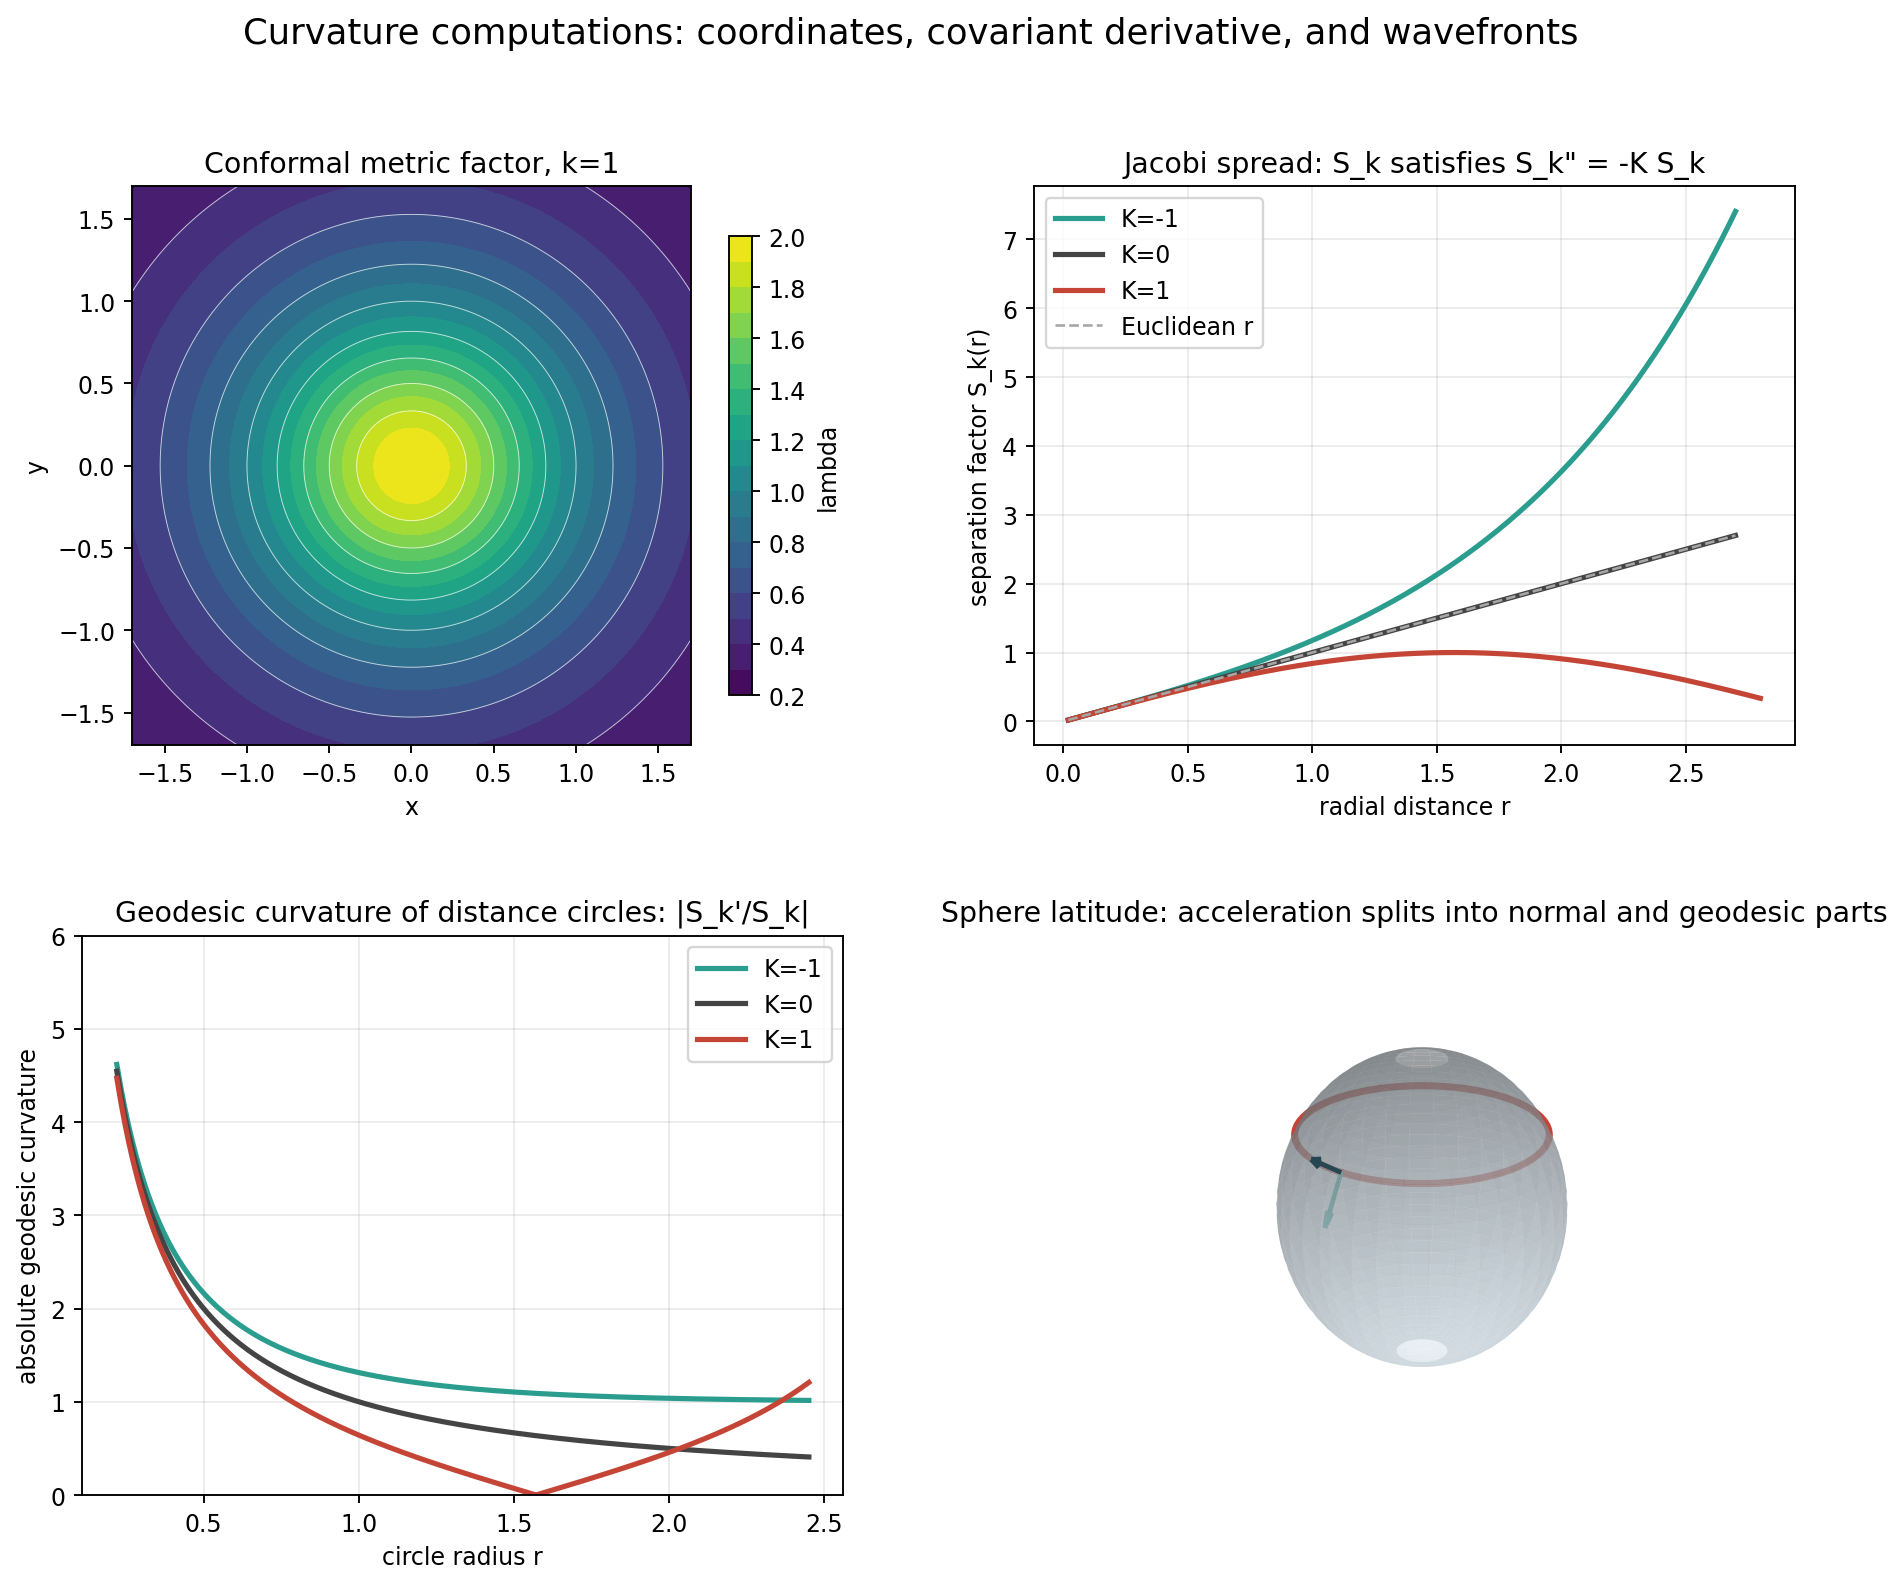

In [3]:
def S_k_numeric(k_value, radius):
    radius = np.asarray(radius, dtype=float)
    if abs(k_value) < 1e-12:
        return radius
    if k_value > 0:
        root = math.sqrt(k_value)
        return np.sin(root * radius) / root
    root = math.sqrt(-k_value)
    return np.sinh(root * radius) / root

def C_k_numeric(k_value, radius):
    radius = np.asarray(radius, dtype=float)
    if abs(k_value) < 1e-12:
        return np.ones_like(radius)
    if k_value > 0:
        return np.cos(math.sqrt(k_value) * radius)
    return np.cosh(math.sqrt(-k_value) * radius)

def model_side_from_radii_angle(k_value, a, b, theta):
    theta = np.asarray(theta, dtype=float)
    if abs(k_value) < 1e-12:
        return np.sqrt(np.maximum(a*a + b*b - 2*a*b*np.cos(theta), 0.0))
    if k_value > 0:
        root = math.sqrt(k_value)
        arg = np.cos(root*a)*np.cos(root*b) + np.sin(root*a)*np.sin(root*b)*np.cos(theta)
        arg = np.clip(arg, -1.0, 1.0)
        return np.arccos(arg) / root
    root = math.sqrt(-k_value)
    arg = np.cosh(root*a)*np.cosh(root*b) - np.sinh(root*a)*np.sinh(root*b)*np.cos(theta)
    arg = np.maximum(arg, 1.0)
    return np.arccosh(arg) / root

sample_r = np.linspace(0.15, 2.25, 10)
model_rows = []
for kval in [-1.0, 0.0, 1.0]:
    for rv in sample_r:
        model_rows.append({
            'k': kval,
            'r': round(float(rv), 5),
            'S_k_r': round(float(S_k_numeric(kval, rv)), 8),
            'circle_geodesic_curvature_abs': round(float(abs(C_k_numeric(kval, rv) / S_k_numeric(kval, rv))), 8),
        })
model_table_path = save_csv(model_rows, TABLE_DIR / 'constant-curvature-models.csv')

xx = np.linspace(-1.7, 1.7, 160)
yy = np.linspace(-1.7, 1.7, 160)
X, Y = np.meshgrid(xx, yy)
lam_num = 2 / (1 + X**2 + Y**2)
R = np.linspace(0.02, 2.7, 400)
R_sphere = np.linspace(0.02, 2.8, 400)

fig = plt.figure(figsize=(13, 10))
grid = fig.add_gridspec(2, 2, hspace=0.34, wspace=0.25)

ax0 = fig.add_subplot(grid[0, 0])
cont = ax0.contourf(X, Y, lam_num, levels=20, cmap='viridis')
ax0.contour(X, Y, lam_num, levels=8, colors='white', linewidths=0.4, alpha=0.7)
ax0.set_title('Conformal metric factor, k=1')
ax0.set_aspect('equal')
ax0.set_xlabel('x')
ax0.set_ylabel('y')
fig.colorbar(cont, ax=ax0, shrink=0.82, label='lambda')

ax1 = fig.add_subplot(grid[0, 1])
for kval, color in [(-1, '#2a9d8f'), (0, '#444444'), (1, '#c44536')]:
    domain = R_sphere if kval == 1 else R
    ax1.plot(domain, S_k_numeric(kval, domain), color=color, lw=2.2, label=f'K={kval}')
ax1.plot(R, R, color='0.65', ls='--', lw=1.1, label='Euclidean r')
ax1.set_title('Jacobi spread: S_k satisfies S_k" = -K S_k')
ax1.set_xlabel('radial distance r')
ax1.set_ylabel('separation factor S_k(r)')
ax1.grid(alpha=0.25)
ax1.legend()

ax2 = fig.add_subplot(grid[1, 0])
r_safe = np.linspace(0.22, 2.45, 360)
for kval, color in [(-1, '#2a9d8f'), (0, '#444444'), (1, '#c44536')]:
    domain = r_safe[r_safe < 2.95] if kval == 1 else r_safe
    kg = np.abs(C_k_numeric(kval, domain) / S_k_numeric(kval, domain))
    ax2.plot(domain, np.clip(kg, 0, 6), color=color, lw=2.2, label=f'K={kval}')
ax2.set_title('Geodesic curvature of distance circles: |S_k\'/S_k|')
ax2.set_xlabel('circle radius r')
ax2.set_ylabel('absolute geodesic curvature')
ax2.set_ylim(0, 6)
ax2.grid(alpha=0.25)
ax2.legend()

ax3 = fig.add_subplot(grid[1, 1], projection='3d')
u = np.linspace(0, 2*np.pi, 72)
v = np.linspace(0.18, np.pi - 0.18, 36)
U, V = np.meshgrid(u, v)
SX = np.sin(V) * np.cos(U)
SY = np.sin(V) * np.sin(U)
SZ = np.cos(V)
ax3.plot_surface(SX, SY, SZ, color='#d8e6ef', edgecolor='none', alpha=0.55)
phi0 = math.pi / 3
lat_x = np.sin(phi0) * np.cos(u)
lat_y = np.sin(phi0) * np.sin(u)
lat_z = np.full_like(u, np.cos(phi0))
ax3.plot(lat_x, lat_y, lat_z, color='#c44536', lw=3, label='latitude')
p0 = np.array([math.sin(phi0), 0.0, math.cos(phi0)])
normal_vec = p0
meridian_vec = np.array([math.cos(phi0), 0.0, -math.sin(phi0)])
ax3.quiver(*p0, *(0.35 * normal_vec), color='#264653', linewidth=2, label='normal curvature')
ax3.quiver(*p0, *(0.35 * meridian_vec), color='#2a9d8f', linewidth=2, label='geodesic curvature')
ax3.set_title('Sphere latitude: acceleration splits into normal and geodesic parts')
ax3.set_box_aspect((1, 1, 1))
ax3.set_axis_off()
ax3.view_init(elev=24, azim=38)

fig.suptitle('Curvature computations: coordinates, covariant derivative, and wavefronts', fontsize=15)
curvature_fig_path = save_matplotlib(fig, FIG_DIR / 'curvature-coordinate-and-wavefronts.png')
plt.close(fig)

display_artifact(curvature_fig_path)


## 3. A Parameter Lab for the Normal-Coordinate Metric

The HTML artifact below is intentionally small: it varies the constant curvature parameter and redraws the factor `S_k(r)` in the normal-coordinate metric. The same slider also reports a model triangle side for two radial sides and a fixed included angle. This is the computational version of the chapter's slogan: curvature is visible in how geodesics spread and therefore in how small triangles compare.


In [4]:
html = """
<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8" />
<title>Constant curvature normal-coordinate lab</title>
<style>
  body { font-family: system-ui, -apple-system, Segoe UI, sans-serif; margin: 24px; color: #1f2933; }
  .wrap { max-width: 920px; }
  canvas { width: 860px; height: 420px; border: 1px solid #cbd5df; background: #fff; }
  .row { display: flex; gap: 18px; align-items: center; margin: 12px 0 18px; }
  input[type=range] { width: 360px; }
  .readout { font-variant-numeric: tabular-nums; font-weight: 650; }
  .note { color: #52606d; max-width: 820px; line-height: 1.45; }
</style>
</head>
<body>
<div class="wrap">
  <h1>Normal-coordinate metric lab</h1>
  <div class="row">
    <label for="k">curvature k</label>
    <input id="k" type="range" min="-1.5" max="1.5" value="0" step="0.01" />
    <span class="readout" id="readout"></span>
  </div>
  <canvas id="plot" width="860" height="420"></canvas>
  <p class="note">The blue curve is S_k(r), the coefficient in ds^2 = dr^2 + S_k(r)^2 dtheta^2. The gray diagonal is the Euclidean value r. Positive curvature pulls the curve below r before the first conjugate scale; negative curvature pushes it above r. The side readout uses two radial sides a=b=0.9 and angle 1.1 radians.</p>
</div>
<script>
function S(k, r) {
  if (Math.abs(k) < 1e-9) return r;
  if (k > 0) { const q = Math.sqrt(k); return Math.sin(q*r)/q; }
  const q = Math.sqrt(-k); return Math.sinh(q*r)/q;
}
function modelSide(k, a, b, theta) {
  if (Math.abs(k) < 1e-9) return Math.sqrt(a*a + b*b - 2*a*b*Math.cos(theta));
  if (k > 0) {
    const q = Math.sqrt(k);
    const z = Math.cos(q*a)*Math.cos(q*b) + Math.sin(q*a)*Math.sin(q*b)*Math.cos(theta);
    return Math.acos(Math.max(-1, Math.min(1, z))) / q;
  }
  const q = Math.sqrt(-k);
  const z = Math.cosh(q*a)*Math.cosh(q*b) - Math.sinh(q*a)*Math.sinh(q*b)*Math.cos(theta);
  return Math.acosh(Math.max(1, z)) / q;
}
function draw() {
  const slider = document.getElementById('k');
  const k = Number(slider.value);
  const side = modelSide(k, 0.9, 0.9, 1.1);
  document.getElementById('readout').textContent = `k=${k.toFixed(2)}; model side=${side.toFixed(4)}`;
  const canvas = document.getElementById('plot');
  const ctx = canvas.getContext('2d');
  ctx.clearRect(0,0,canvas.width,canvas.height);
  const left=58, right=28, top=24, bottom=46;
  const W=canvas.width-left-right, H=canvas.height-top-bottom;
  const rMax = 2.6, yMax = 4.2;
  function px(r) { return left + W*r/rMax; }
  function py(y) { return top + H - H*y/yMax; }
  ctx.strokeStyle = '#d0d7de'; ctx.lineWidth = 1;
  for (let i=0; i<=6; i++) { const yy=i*yMax/6; ctx.beginPath(); ctx.moveTo(left, py(yy)); ctx.lineTo(left+W, py(yy)); ctx.stroke(); }
  for (let i=0; i<=6; i++) { const rr=i*rMax/6; ctx.beginPath(); ctx.moveTo(px(rr), top); ctx.lineTo(px(rr), top+H); ctx.stroke(); }
  ctx.strokeStyle = '#808891'; ctx.setLineDash([7,5]); ctx.beginPath(); ctx.moveTo(px(0), py(0)); ctx.lineTo(px(rMax), py(rMax)); ctx.stroke(); ctx.setLineDash([]);
  ctx.strokeStyle = '#1f77b4'; ctx.lineWidth = 3; ctx.beginPath();
  for (let i=0; i<=360; i++) { const r=i*rMax/360; const y=S(k,r); if (i===0) ctx.moveTo(px(r),py(y)); else ctx.lineTo(px(r),py(y)); }
  ctx.stroke();
  ctx.fillStyle = '#1f2933'; ctx.font = '14px system-ui'; ctx.fillText('r', left+W-8, top+H+30); ctx.fillText('S_k(r)', 8, top+16);
}
document.getElementById('k').addEventListener('input', draw);
draw();
</script>
</body>
</html>
"""
html_path = HTML_DIR / 'constant-curvature-metric-lab.html'
html_path.write_text(html, encoding='utf-8')
display_artifact(html_path, width=900, height=580)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 4. Comparison Theorems as a Residual Plot

Rauch comparison is an ODE statement about Jacobi fields: under a curvature inequality, the length of an orthogonal variation field is ordered as long as the field does not pass through a zero. The triangle theorem then packages that ODE comparison into a metric statement by using normal coordinates. Radial distances and the included angle are kept fixed; the opposite side becomes the inspected quantity.

For constant-curvature model triangles with radial sides `a=b=0.9`, the side opposite the included angle decreases as curvature increases. This monotone residual is the model behavior that local Cartan-Alexandrov-Toponogov comparison transfers to a Riemannian surface with a curvature bound.


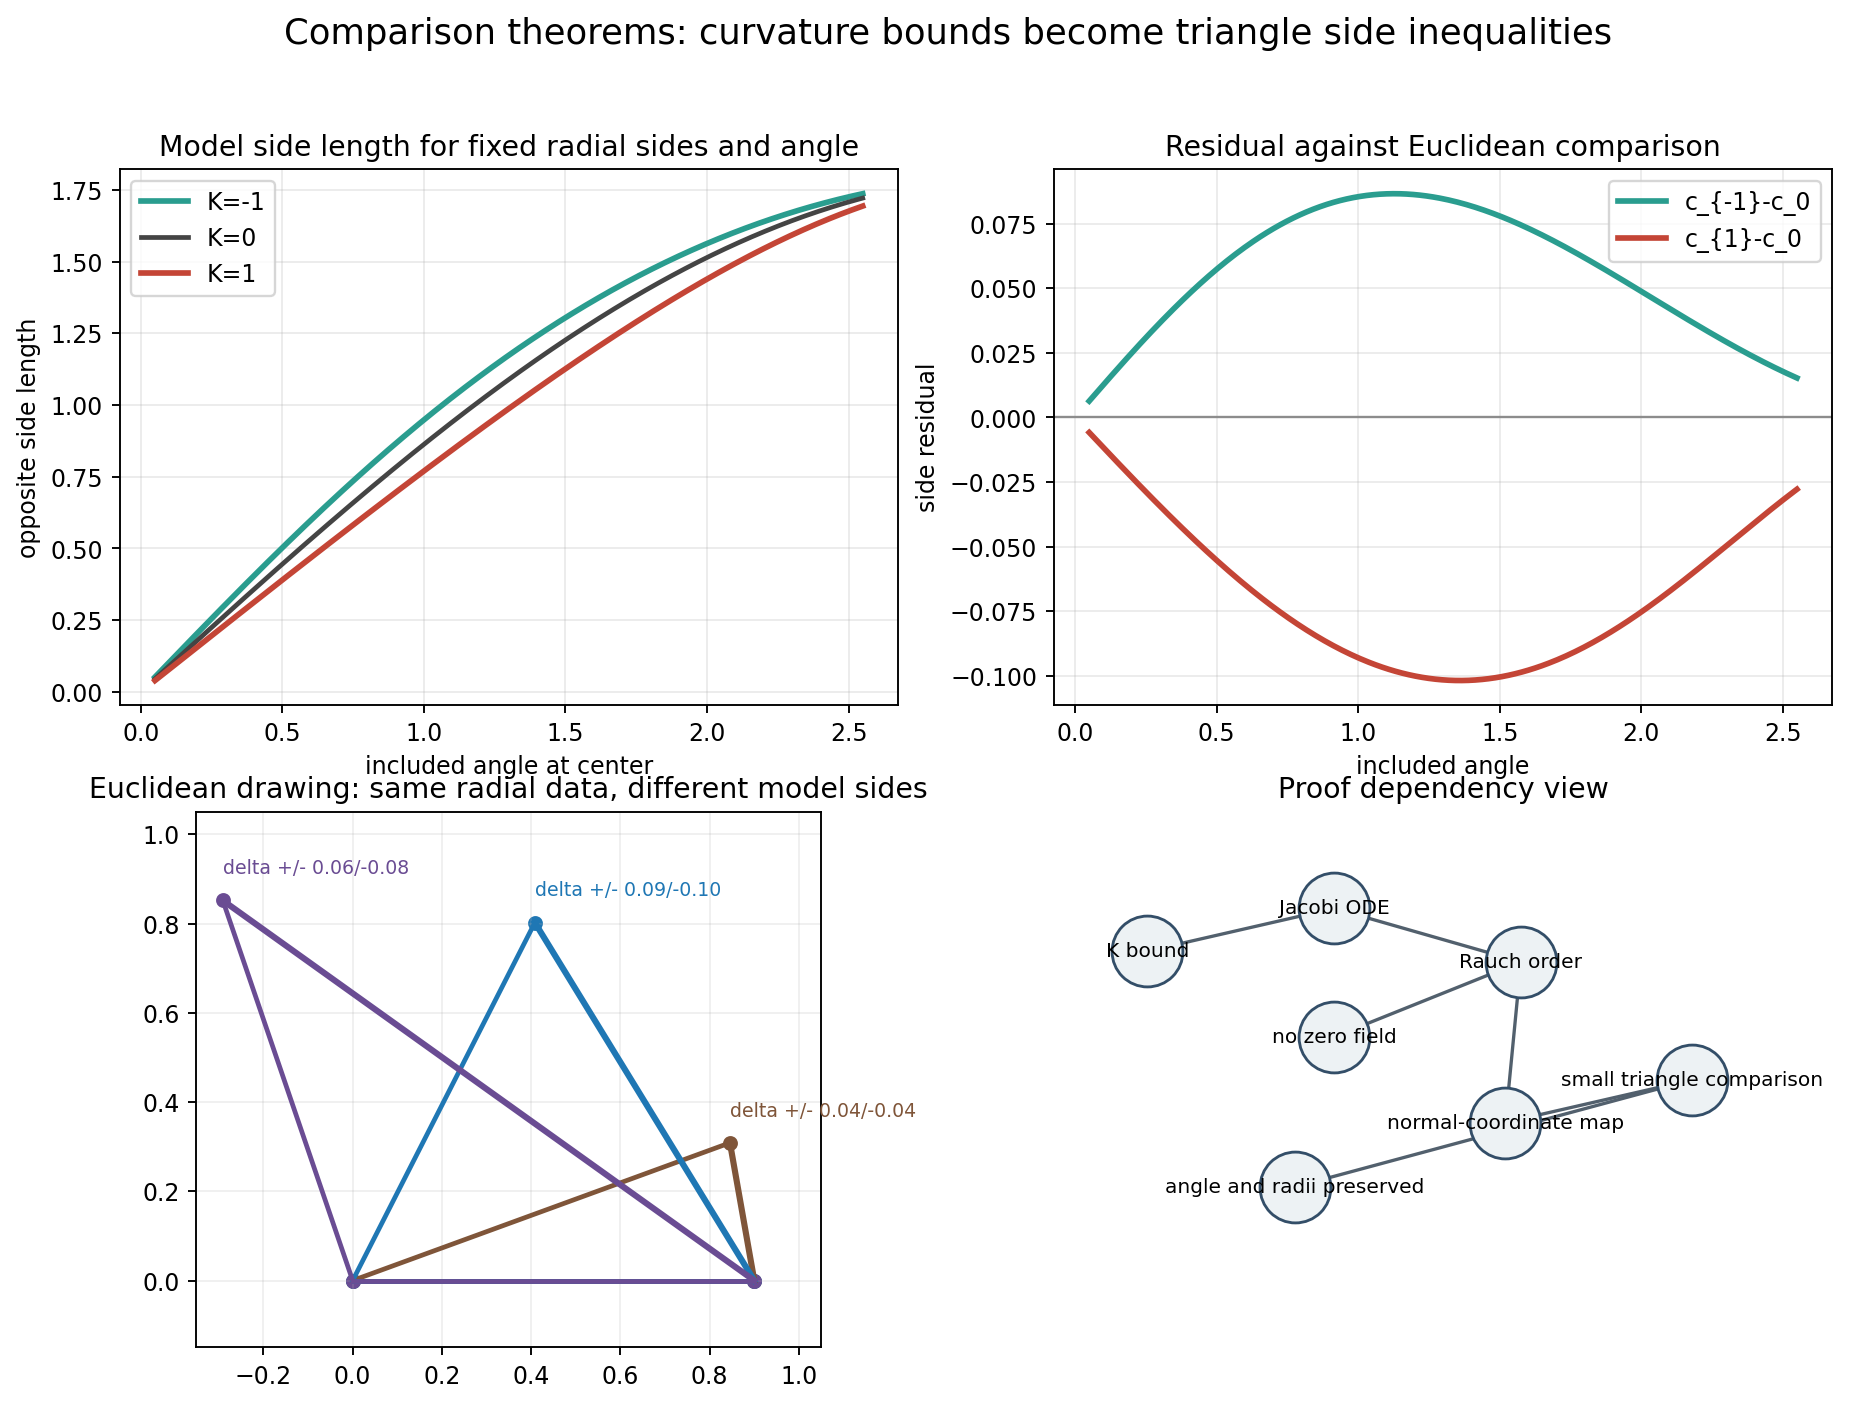

{'a': 0.9,
 'b': 0.9,
 'theta_min': 0.05,
 'theta_max': 2.55,
 'positive_curvature_side_minus_euclidean_max': -0.005830543829050933,
 'positive_curvature_side_minus_euclidean_min': -0.10179145888067098,
 'negative_curvature_side_minus_euclidean_min': 0.006319547052345109,
 'negative_curvature_side_minus_euclidean_max': 0.08653405471807818,
 'sign_contract': 'for this fixed radial data, K=1 sides are below Euclidean and K=-1 sides are above Euclidean'}

In [5]:
theta = np.linspace(0.05, 2.55, 320)
a = b = 0.9
side_neg = model_side_from_radii_angle(-1.0, a, b, theta)
side_zero = model_side_from_radii_angle(0.0, a, b, theta)
side_pos = model_side_from_radii_angle(1.0, a, b, theta)
residual_neg = side_neg - side_zero
residual_pos = side_pos - side_zero

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax = axes[0, 0]
ax.plot(theta, side_neg, color='#2a9d8f', lw=2.4, label='K=-1')
ax.plot(theta, side_zero, color='#444444', lw=2.0, label='K=0')
ax.plot(theta, side_pos, color='#c44536', lw=2.4, label='K=1')
ax.set_title('Model side length for fixed radial sides and angle')
ax.set_xlabel('included angle at center')
ax.set_ylabel('opposite side length')
ax.grid(alpha=0.25)
ax.legend()

ax = axes[0, 1]
ax.axhline(0, color='0.55', lw=1)
ax.plot(theta, residual_neg, color='#2a9d8f', lw=2.4, label='c_{-1}-c_0')
ax.plot(theta, residual_pos, color='#c44536', lw=2.4, label='c_{1}-c_0')
ax.set_title('Residual against Euclidean comparison')
ax.set_xlabel('included angle')
ax.set_ylabel('side residual')
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1, 0]
angles = [0.35, 1.1, 1.9]
colors = ['#7f5539', '#1f77b4', '#6a4c93']
for angle, color in zip(angles, colors):
    p = np.array([a, 0.0])
    q = np.array([b * math.cos(angle), b * math.sin(angle)])
    ax.plot([0, p[0]], [0, p[1]], color=color, lw=2)
    ax.plot([0, q[0]], [0, q[1]], color=color, lw=2)
    ax.plot([p[0], q[0]], [p[1], q[1]], color=color, lw=2.6)
    ax.scatter([0, p[0], q[0]], [0, p[1], q[1]], color=color, s=28)
    idx = int(np.argmin(abs(theta - angle)))
    cneg = model_side_from_radii_angle(-1.0, a, b, angle)
    cpos = model_side_from_radii_angle(1.0, a, b, angle)
    ax.text(q[0], q[1] + 0.06, f'delta +/- {float(cneg-side_zero[idx]):.2f}/{float(cpos-side_zero[idx]):.2f}', fontsize=8, color=color)
ax.set_title('Euclidean drawing: same radial data, different model sides')
ax.set_aspect('equal')
ax.set_xlim(-0.35, 1.05)
ax.set_ylim(-0.15, 1.05)
ax.grid(alpha=0.2)

ax = axes[1, 1]
ax.set_title('Proof dependency view')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
nodes = {
    'K bound': (0.12, 0.74),
    'Jacobi ODE': (0.36, 0.82),
    'no zero field': (0.36, 0.58),
    'Rauch order': (0.60, 0.72),
    'normal-coordinate map': (0.58, 0.42),
    'angle and radii preserved': (0.31, 0.30),
    'small triangle comparison': (0.82, 0.50),
}
edges = [
    ('K bound', 'Jacobi ODE'),
    ('Jacobi ODE', 'Rauch order'),
    ('no zero field', 'Rauch order'),
    ('Rauch order', 'normal-coordinate map'),
    ('normal-coordinate map', 'small triangle comparison'),
    ('angle and radii preserved', 'small triangle comparison'),
]
for name, (px, py) in nodes.items():
    ax.scatter([px], [py], s=900, color='#edf2f4', edgecolor='#334e68', linewidth=1.2, zorder=3)
    ax.text(px, py, name, ha='center', va='center', fontsize=8.5, zorder=4)
for start, end in edges:
    x0, y0 = nodes[start]
    x1, y1 = nodes[end]
    arrow = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='->', mutation_scale=12, lw=1.4, color='#52606d')
    ax.add_patch(arrow)

fig.suptitle('Comparison theorems: curvature bounds become triangle side inequalities', fontsize=15)
comparison_fig_path = save_matplotlib(fig, FIG_DIR / 'comparison-triangle-residuals.png')
plt.close(fig)

comparison_checks = {
    'a': a,
    'b': b,
    'theta_min': float(theta.min()),
    'theta_max': float(theta.max()),
    'positive_curvature_side_minus_euclidean_max': float(np.max(residual_pos)),
    'positive_curvature_side_minus_euclidean_min': float(np.min(residual_pos)),
    'negative_curvature_side_minus_euclidean_min': float(np.min(residual_neg)),
    'negative_curvature_side_minus_euclidean_max': float(np.max(residual_neg)),
    'sign_contract': 'for this fixed radial data, K=1 sides are below Euclidean and K=-1 sides are above Euclidean',
}
comparison_path = save_json(comparison_checks, CHECK_DIR / 'comparison-residual-checks.json')

assert np.max(residual_pos) < 1e-10
assert np.min(residual_neg) > -1e-10

display_artifact(comparison_fig_path)
comparison_checks


## 5. Source Coverage Map

The source span is not copied into the notebook. Instead, the table below records how each section's mathematical role is represented. This is useful for review: a missing section should correspond either to an explicit gap or to a conscious decision that its proof is carried by another visual or check.


In [6]:
coverage = {
    'chapter': 'Curvature of Riemannian Metrics',
    'source_span': {'printed': '209-240', 'pdf': '224-255'},
    'pdf_used_for': 'structure, terminology, theorem orientation, and page spans only',
    'sections': source_sections,
    'coverage': [
        {
            'section': '6.1',
            'covered_by': ['curvature-symbolic-checks.json', 'curvature-coordinate-and-wavefronts.png'],
            'learner_inspection_target': 'Christoffel symbols are the coordinate correction terms in the geodesic equation.',
            'validation': 'conformal Christoffel residuals and constant curvature residual vanish exactly',
        },
        {
            'section': '6.2',
            'covered_by': ['curvature-symbolic-checks.json'],
            'learner_inspection_target': 'The Levi-Civita derivative is the unique product-rule-preserving replacement for componentwise differentiation.',
            'validation': 'metric-compatible conformal Christoffel pattern is checked symbolically',
        },
        {
            'section': '6.3',
            'covered_by': ['curvature-coordinate-and-wavefronts.png', 'constant-curvature-models.csv'],
            'learner_inspection_target': 'Geodesic curvature is tangential acceleration; normal curvature is the extrinsic normal component.',
            'validation': 'distance-circle geodesic curvature is computed as |S_k prime / S_k|',
        },
        {
            'section': '6.4',
            'covered_by': ['curvature-coordinate-and-wavefronts.png', 'constant-curvature-metric-lab.html'],
            'learner_inspection_target': 'Gaussian curvature appears as the coefficient in the Jacobi equation and as third-order normal-coordinate distortion.',
            'validation': 'S_k double-prime plus k S_k is zero for k=-1,0,1',
        },
        {
            'section': '6.5',
            'covered_by': ['comparison-triangle-residuals.png', 'comparison-residual-checks.json'],
            'learner_inspection_target': 'Rauch comparison orders Jacobi field lengths, which normal coordinates convert into local triangle comparison.',
            'validation': 'constant-curvature triangle side residuals have the expected signs',
        },
    ],
    'known_gaps': [
        'The notebook treats the two-dimensional case emphasized by the source span; higher-dimensional sectional curvature is noted but not developed.',
        'The full analytic proof of Levi-Civita existence and the index-form discussion of conjugate points are represented by symbolic/proof scaffolds rather than reproduced as long text.',
    ],
}
visual_storyboard = {
    'chapter': 'Curvature of Riemannian Metrics',
    'source_span': {'printed': '209-240', 'pdf': '224-255'},
    'items': [
        {'artifact': 'curvature-coordinate-and-wavefronts.png', 'concept': 'coordinate curvature, covariant derivative, geodesic and normal curvature, Jacobi spread', 'validation': 'symbolic Christoffel/K checks and nonblank image statistics'},
        {'artifact': 'constant-curvature-metric-lab.html', 'concept': 'normal-coordinate metric coefficient S_k(r)', 'validation': 'HTML slider exists and S_k formulas share the checked Jacobi residual'},
        {'artifact': 'comparison-triangle-residuals.png', 'concept': 'Rauch and local triangle comparison', 'validation': 'positive and negative model residual signs are asserted'},
    ],
}
visual_storyboard_path = save_json(visual_storyboard, CHECK_DIR / 'visual-storyboard.json')
coverage_path = save_json(coverage, CHECK_DIR / 'source-coverage.json')
display_artifact(coverage_path)
coverage


`artifacts/chapter-06/checks/source-coverage.json`

{'chapter': 'Curvature of Riemannian Metrics',
 'source_span': {'printed': '209-240', 'pdf': '224-255'},
 'pdf_used_for': 'structure, terminology, theorem orientation, and page spans only',
 'sections': [{'number': '6.1',
   'title': 'Motivation: Coordinate Computations',
   'printed_start': 211,
   'pdf_start': 226},
  {'number': '6.2',
   'title': 'Covariant Derivative',
   'printed_start': 214,
   'pdf_start': 229},
  {'number': '6.3',
   'title': 'Geodesic and Gaussian Curvatures',
   'printed_start': 221,
   'pdf_start': 236},
  {'number': '6.4',
   'title': 'Geometric Meaning of Gaussian Curvature',
   'printed_start': 226,
   'pdf_start': 241},
  {'number': '6.5',
   'title': 'Comparison Theorems',
   'printed_start': 237,
   'pdf_start': 252}],
 'coverage': [{'section': '6.1',
   'covered_by': ['curvature-symbolic-checks.json',
    'curvature-coordinate-and-wavefronts.png'],
   'learner_inspection_target': 'Christoffel symbols are the coordinate correction terms in the geodesic

## Applied Lab

Pick one of the three computational contracts and deliberately break a hypothesis.

- Change the conformal factor away from `2/(1+k r^2)` and watch the Gaussian curvature stop being constant.
- Push positive-curvature normal coordinates toward the first zero of `S_k`; this is where the no-conjugate/no-focal restriction starts to matter.
- Compare triangle sides after changing the included angle but not the radial distances; the sign of the residual should still track the model curvature ordering.

The habit to practice is precise: name the invariant, name the hypothesis that protects it, and say whether a residual is mathematical information or numerical error.


## Final Sanity Checks

The final cell asserts the exact identities, verifies that all generated artifacts exist and are nonblank, and writes a compact JSON summary for downstream QC. The checks are intentionally redundant: a figure can render while the algebra is wrong, and an exact identity can pass while an artifact path is stale.


In [7]:
artifact_paths = [
    curvature_fig_path,
    comparison_fig_path,
    html_path,
    symbolic_path,
    comparison_path,
    coverage_path,
    visual_storyboard_path,
    model_table_path,
]

image_stats = {}
for image_path in [curvature_fig_path, comparison_fig_path]:
    pixels = plt.imread(image_path)
    image_stats[relative(image_path)] = {
        'shape': list(pixels.shape),
        'std': float(np.std(pixels)),
        'mean': float(np.mean(pixels)),
    }
    assert float(np.std(pixels)) > 0.01

assert html_path.exists() and 'input id="k" type="range"' in html_path.read_text(encoding='utf-8')
assert all(path.exists() and path.stat().st_size > 80 for path in artifact_paths)
assert all(value == 0 for value in conformal_targets.values())
assert curvature_residual == 0
assert all(value == 0 for value in jacobi_residuals.values())
assert np.max(residual_pos) < 1e-10
assert np.min(residual_neg) > -1e-10
assert {entry['section'] for entry in coverage['coverage']} == {'6.1', '6.2', '6.3', '6.4', '6.5'}

final_sanity = {
    'chapter': '06-curvature-of-riemannian-metrics',
    'source_span': {'printed': '209-240', 'pdf': '224-255'},
    'standalone_contract': True,
    'pdf_used_for': 'structure and source orientation only',
    'artifacts': [
        {'path': relative(path), 'exists': path.exists(), 'bytes': path.stat().st_size if path.exists() else 0}
        for path in artifact_paths
    ],
    'exact_symbolic_checks': {
        'conformal_christoffel_residuals_zero': all(value == 0 for value in conformal_targets.values()),
        'stereographic_constant_curvature_residual_zero': curvature_residual == 0,
        'constant_model_jacobi_residuals_zero': all(value == 0 for value in jacobi_residuals.values()),
    },
    'comparison_checks': comparison_checks,
    'image_stats': image_stats,
    'known_gaps': coverage['known_gaps'],
}
final_sanity_path = save_json(final_sanity, CHECK_DIR / 'final-sanity.json')
final_sanity


{'chapter': '06-curvature-of-riemannian-metrics',
 'source_span': {'printed': '209-240', 'pdf': '224-255'},
 'standalone_contract': True,
 'pdf_used_for': 'structure and source orientation only',
 'artifacts': [{'path': 'artifacts/chapter-06/figures/curvature-coordinate-and-wavefronts.png',
   'exists': True,
   'bytes': 338737},
  {'path': 'artifacts/chapter-06/figures/comparison-triangle-residuals.png',
   'exists': True,
   'bytes': 276619},
  {'path': 'artifacts/chapter-06/html/constant-curvature-metric-lab.html',
   'exists': True,
   'bytes': 3538},
  {'path': 'artifacts/chapter-06/checks/curvature-symbolic-checks.json',
   'exists': True,
   'bytes': 561},
  {'path': 'artifacts/chapter-06/checks/comparison-residual-checks.json',
   'exists': True,
   'bytes': 479},
  {'path': 'artifacts/chapter-06/checks/source-coverage.json',
   'exists': True,
   'bytes': 3276},
  {'path': 'artifacts/chapter-06/checks/visual-storyboard.json',
   'exists': True,
   'bytes': 855},
  {'path': 'ar

## Takeaways

Curvature in this chapter is not introduced as a decorative scalar. It enters three equivalent-looking jobs:

1. It is the coordinate scalar left after Christoffel correction removes coordinate noise.
2. It is the coefficient in the Jacobi equation controlling the spread of nearby geodesics.
3. It is the quantity that lets ODE comparison become local triangle comparison.

That is why this chapter belongs in a metric-geometry course: once the differential machinery proves the right local comparison theorem, later chapters can work synthetically with curvature bounds without reopening the coordinate calculation every time.
